# BEE 4750 Homework 4: Linear Programming and Capacity Expansion

**Name**: Priya Shah, Bailey Belinger, Camila Monter

**ID**: 5244508 (ps742), 5277347 (bcb87), 5244001 (cm755)

> **Due Date**
>
> Thursday, 10/31/24, 9:00pm

## Overview

### Instructions

-   Problem 1 asks you to formulate and solve a resource allocation
    problem using linear programming.
-   Problem 2 asks you to formulate, solve, and analyze a standard
    generating capacity expansion problem.
-   Problem 3 (5750 only) asks you to add a CO<sub>2</sub> constraint to
    the capacity expansion problem and identify changes in the resulting
    solution.

### Load Environment

The following code loads the environment and makes sure all needed
packages are installed. This should be at the start of most Julia
scripts.

In [17]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.instantiate()

  Activating project at `~/Downloads/BEE4750/hw4-last-3-brain-cells`


In [18]:
using JuMP
using HiGHS
using DataFrames
using Plots
using Measures
using CSV
using MarkdownTables
using LinearAlgebra

## Problems (Total: 50/60 Points)

### Problem 1 (20 points)

A farmer has access to a pesticide which can be used on corn, soybeans,
and wheat fields, and costs \$70/kg-ha-yr to apply. The crop yields the
farmer can obtain following crop yields by applying varying rates of
pesticides to the field are shown in
<a href="#tbl-yields" class="quarto-xref">Table 1</a>.

| Application Rate (kg/ha) | Soybean (kg/ha) | Wheat (kg/ha) | Corn (kg/ha) |
|:------------------------:|:---------------:|:-------------:|:------------:|
|            0             |      2900       |     3500      |     5900     |
|            1             |      3800       |     4100      |     6700     |
|            2             |      4400       |     4200      |     7900     |

Table 1: Crop yields from applying varying pesticide rates for Problem
1.

The costs of production, *excluding pesticides*, for each crop, and
selling prices, are shown in
<a href="#tbl-costs" class="quarto-xref">Table 2</a>.

|   Crop   | Production Cost (\$/ha-yr) | Selling Price (\$/kg) |
|:--------:|:--------------------------:|:---------------------:|
| Soybeans |            350             |         0.36          |
|  Wheat   |            280             |         0.27          |
|   Corn   |            390             |         0.22          |

Table 2: Costs of crop production, excluding pesticides, and selling
prices for each crop.

Recently, environmental authorities have declared that farms cannot have
an *average* application rate on soybeans, wheat, and corn which exceeds
0.8, 0.7, and 0.6 kg/ha, respectively. The farmer has asked you for
advice on how they should plant crops and apply pesticides to maximize
profits over 130 total ha while remaining in regulatory compliance if
demand for each crop (which is the maximum the market would buy) this
year is 250,000 kg?

**In this problem**:

-   Formulate a linear program for this resource allocation problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations). **Tip: Make sure that all of your constraints are
    linear**.
-   Implement the program in `JuMP.jl` and find the solution. How many
    ha should the farmer dedicate to each crop and with what pesticide
    application rate(s)? How much profit will the farmer expect to make?
-   The farmer has an opportunity to buy an extra 10 ha of land. How
    much extra profit would this land be worth to the farmer? Discuss
    why this value makes sense and whether you would recommend the
    farmer should make the purchase.

**Derivation**

The goal is to allocate land among three crops while determining the optimal pesticide application rate for each crop to maximize profit. To do this, we introduced three sets of **decision variables**:
- $a_s[i]$ represents the area of land allocated to soybeans with different pesticide application rates. Specifically:
    - $a_s[1]$: Area of land used for soybeans with no pesticides.
    - $a_s[2]$: Area of land used for soybeans with 1 kg/ha of pesticide.
    - $a_s[3]$: Area of land used for soybeans with 2 kg/ha of pesticide.
- $a_w[i]$ represents the area of land allocated to wheat.
    - $a_w[1]$: Area of land used for wheat with no pesticides.
    - $a_w[2]$: Area of land used for wheat with 1 kg/ha of pesticide.
    - $a_w[3]$: Area of land used for wheat with 2 kg/ha of pesticide.
- $a_c[i]$ represents the area of land allocated to corn. 
    - $a_c[1]$: Area of land used for corn with no pesticides.
    - $a_c[2]$: Area of land used for corn with 1 kg/ha of pesticide.
    - $a_c[3]$: Area of land used for corn with 2 kg/ha of pesticide.

The **objective function** of our model is to maximize the profit. This is broken down into three differnt parts: application cost, production cost, and the sell price. These can be calculated using the following equations with values from Tables 1 and 2:

$\text{Sell Price} = \sum_{j \in \{s, w, c\}} \text{sp}_j \cdot \sum_{i=1}^{3} a_{j,i} \cdot y_{j,i}$

$\text{Production Cost} = \sum_{j \in \{s, w, c\}} \text{pc}_j \cdot \sum_{i=1}^{3} a_{j,i}$

$\text{Application Cost} = \text{appc} \cdot \sum_{j \in \{s, w, c\}} \sum_{i=1}^{3} i \cdot a_{j,i}$

Where:

$j \in \{s, w, c\}$ represents each crop type (soybeans, wheat, and corn)

$a_{j,i}$ represents the area planted in crop $j$ at $i$.

$y_{j,i}$ is the yield of crop $j$ at $i$.

$\text{sp}_j$ is the selling price per kilogram for crop $j$.

$\text{pc}_j$ is the production cost per hectare per year for crop $j$.

From these we can caluculate the profit: 

$\text{Profit = Sell Price - Production Cost - Application Cost}$



In order to run our model, we need to set up our **constraints**. For this problem, there are three differnt types of constraints:

1. **Rate of Pesticide Application** - the application rate must be less than 0.8, 0.7, and 0.6 for soybeans, wheat, and corn, respectively.

    $\text{Soybean pesticide rate constraint:} \quad a_{s,2} + 2 \cdot a_{s,3} \leq 0.8 \cdot \sum_{i=1}^{3} a_{s,i}$

    $\text{Wheat pesticide rate constraint:} \quad a_{w,2} + 2 \cdot a_{w,3} \leq 0.7 \cdot \sum_{i=1}^{3} a_{w,i}$

    $\text{Corn pesticide rate constraint:} \quad a_{c,2} + 2 \cdot a_{c,3} \leq 0.6 \cdot \sum_{i=1}^{3} a_{c,i}$

2. **Maximum Demand** - the production of each crop must be less than the maximum demand of 250,000kg.

    $\text{Maximum demand for soybeans:} \quad P_s \leq 250{,}000$

    $\text{Maximum demand for wheat:} \quad P_w \leq 250{,}000$

    $\text{Maximum demand for corn:} \quad P_c \leq 250{,}000$

    Where P_s, P_w, and P_c represent the production of soybeans, wheat, and corn, respectively.

3. **Total Land Area** - the total land area must not exceed 130ha.
    
    $\text{Total land area constraint:} \quad \sum_{j \in \{s, w, c\}} \sum_{i=1}^{3} a_{j,i} \leq 130$

4. **Non-Negativity** - ensures that the area of land each crop uses is greater than zero.
    
    $\quad a_{s,i} \geq 0, \quad \forall i \in \{1, 2, 3\}$

    $\quad a_{w,i} \geq 0, \quad \forall i \in \{1, 2, 3\}$

    $\quad a_{c,i} \geq 0, \quad \forall i \in \{1, 2, 3\}$

Now that we have set up our objective function and constraints, we can run our model.

In [19]:
# Defining variables
appc = 70 # $/kg-ha-yr

soy0 = 2900 # kg/ha
soy1 = 3800 # kg/ha
soy2 = 4400 # kg/ha
sp_soy = 0.36 # $/kg
pc_soy = 350 # $/ha-yr

wheat0 = 3500 # kg/ha
wheat1 = 4100 # kg/ha
wheat2 = 4200 # kg/ha
sp_wheat = 0.27 # $/kg
pc_wheat = 280 # $/ha-yr 

corn0 = 5900 # kg/ha
corn1 = 6700 # kg/ha
corn2 = 7900 # kg/ha
sp_corn = 0.22 # $/kg
pc_corn = 390 # $/ha-yr

crop_model = Model(HiGHS.Optimizer)
@variable(crop_model, as[1:3]>=0)
@variable(crop_model, aw[1:3]>=0)
@variable(crop_model, ac[1:3]>=0)

Ps = as[1]*soy0 + as[2]*soy1 + as[3]*soy2
Pw = aw[1]*wheat0 + aw[2]*wheat1 + aw[3]*wheat2
Pc = ac[1]*corn0 + ac[2]*corn1 + ac[3]*corn2

#Rs = (as[2] + 2*as[3])*(1/(sum(as)))
#Rw = (aw[2] + 2*aw[3])*(1/(sum(aw)))
#Rc = (ac[2] + 2*ac[3])*(1/(sum(ac)))

sell_price = sp_soy*Ps + sp_wheat*Pw + sp_corn*Pc
prod_cost = pc_soy*sum(as)+ pc_wheat*sum(aw) + pc_corn*sum(ac)
#app_cost = appc*(Ps + Pw + Pc)*(sum(as) + sum(aw) + sum(ac))
app_cost = appc * (as[2] + 2*as[3] + aw[2] + 2*aw[3] + ac[2] + 2*ac[3]) #$/ha-yr
profit = sell_price - prod_cost - app_cost

@objective(crop_model, Max, profit)

@constraint(crop_model, Rs_constraint, as[2] + 2*as[3] <= 0.8 * sum(as))  # Soybean pesticide rate constraint
@constraint(crop_model, Rw_constraint, aw[2] + 2*aw[3] <= 0.7 * sum(aw))  # Wheat pesticide rate constraint
@constraint(crop_model, Rc_constraint, ac[2] + 2*ac[3] <= 0.6 * sum(ac))  # Corn pesticide rate constraint

# Constraints on total production (demand constraints)
@constraint(crop_model, Ps_constraint, Ps <= 250000)  # Maximum demand for soybeans
@constraint(crop_model, Pw_constraint, Pw <= 250000)  # Maximum demand for wheat
@constraint(crop_model, Pc_constraint, Pc <= 250000)  # Maximum demand for corn

# Constraint on total land area
@constraint(crop_model, land_constraint, sum(as) + sum(aw) + sum(ac) <= 130)

# Optimize the model
optimize!(crop_model)

# Display the optimized values
println("Optimal soybean areas: ", value.(as))
println("Optimal wheat areas: ", value.(aw))
println("Optimal corn areas: ", value.(ac))
profit1 = objective_value(crop_model)
println("Total profit: ", profit1)

@show shadow_price(land_constraint)

Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170297740e+02 Ph1: 7(28.3601); Du: 9(181.703) 0s
          7     1.1674116702e+05 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 7
Objective value     :  1.1674116702e+05
HiGHS run time      :          0.00
Optimal soybean areas: [13.812154696132604, 55.24861878453038, 0.0]
Optimal wheat areas: [6.743306417339563, 15.734381640458977, 0.0]
Optimal corn areas: [26.92307692307692, 0.0, 11.538461538461547]
Total profit: 116741.16702082448
shadow_pric

729.4

**Solution**

The farmer should dedicate a total of 69.06 ha to soybeans, with 14 ha with no pesticides, 55 ha with 1 kg/ha of pesticade, and 0 ha with 2 kg/ha. 

The farmer should dedicate a total of 22.48 ha to wheat, with 7 ha with no pesticides, 16 ha with 1 kg/ha of pesticade, and 0 ha with 2 kg/ha.  

Lastly, the farmer should dedicate a total of 38.46 ha to corn, with 27 ha with no pesticides, 0 ha with 1 kg/ha of pesticade, and 12 ha with 2 kg/ha. 

The would give the farmer a profit of $11,6741. 

The shadow price of the land contraint is $729.40, which means with each unit increase in ha, the total profit can increase by this amount. 

In [20]:
# Defining variables
appc = 70 # $/kg-ha-yr

soy0 = 2900 # kg/ha
soy1 = 3800 # kg/ha
soy2 = 4400 # kg/ha
sp_soy = 0.36 # $/kg
pc_soy = 350 # $/ha-yr

wheat0 = 3500 # kg/ha
wheat1 = 4100 # kg/ha
wheat2 = 4200 # kg/ha
sp_wheat = 0.27 # $/kg
pc_wheat = 280 # $/ha-yr 

corn0 = 5900 # kg/ha
corn1 = 6700 # kg/ha
corn2 = 7900 # kg/ha
sp_corn = 0.22 # $/kg
pc_corn = 390 # $/ha-yr

crop_model = Model(HiGHS.Optimizer)
@variable(crop_model, as[1:3]>=0)
@variable(crop_model, aw[1:3]>=0)
@variable(crop_model, ac[1:3]>=0)

Ps = as[1]*soy0 + as[2]*soy1 + as[3]*soy2
Pw = aw[1]*wheat0 + aw[2]*wheat1 + aw[3]*wheat2
Pc = ac[1]*corn0 + ac[2]*corn1 + ac[3]*corn2

#Rs = (as[2] + 2*as[3])*(1/(sum(as)))
#Rw = (aw[2] + 2*aw[3])*(1/(sum(aw)))
#Rc = (ac[2] + 2*ac[3])*(1/(sum(ac)))

sell_price = sp_soy*Ps + sp_wheat*Pw + sp_corn*Pc
prod_cost = pc_soy*sum(as)+ pc_wheat*sum(aw) + pc_corn*sum(ac)
#app_cost = appc*(Ps + Pw + Pc)*(sum(as) + sum(aw) + sum(ac))
app_cost = appc * (as[2] + 2*as[3] + aw[2] + 2*aw[3] + ac[2] + 2*ac[3]) #$/ha-yr
profit = sell_price - prod_cost - app_cost

@objective(crop_model, Max, profit)

@constraint(crop_model, Rs_constraint, as[2] + 2*as[3] <= 0.8 * sum(as))  # Soybean pesticide rate constraint
@constraint(crop_model, Rw_constraint, aw[2] + 2*aw[3] <= 0.7 * sum(aw))  # Wheat pesticide rate constraint
@constraint(crop_model, Rc_constraint, ac[2] + 2*ac[3] <= 0.6 * sum(ac))  # Corn pesticide rate constraint

# Constraints on total production (demand constraints)
@constraint(crop_model, Ps <= 250000)  # Maximum demand for soybeans
@constraint(crop_model, Pw <= 250000)  # Maximum demand for wheat
@constraint(crop_model, Pc <= 250000)  # Maximum demand for corn

# Constraint on total land area
@constraint(crop_model, sum(as) + sum(aw) + sum(ac) <= 140)

# Optimize the model
optimize!(crop_model)

# Display the optimized values
println("Optimal soybean areas: ", value.(as))
println("Optimal wheat areas: ", value.(aw))
println("Optimal corn areas: ", value.(ac))
profit2 = objective_value(crop_model)
println("Total profit: ", profit2)
additional_p = profit2 - profit1
println("Total additional profit: ", additional_p)


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [2e-01, 8e+03]
  Cost   [7e+02, 1e+03]
  Bound  [0e+00, 0e+00]
  RHS    [1e+02, 2e+05]
Presolving model
7 rows, 9 cols, 27 nonzeros  0s
7 rows, 9 cols, 27 nonzeros  0s
Presolve : Reductions: rows 7(-0); columns 9(-0); elements 27(-0) - Not reduced
Problem not reduced by presolve: solving the LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.8170297740e+02 Ph1: 7(28.3601); Du: 9(181.703) 0s
          7     1.2403516702e+05 Pr: 0(0) 0s
Model   status      : Optimal
Simplex   iterations: 7
Objective value     :  1.2403516702e+05
HiGHS run time      :          0.00
Optimal soybean areas: [13.8121546961326, 55.24861878453038, 0.0]
Optimal wheat areas: [9.743306417339566, 22.734381640458977, 0.0]
Optimal corn areas: [26.923076923076938, 0.0, 11.538461538461544]
Total profit: 124035.16702082449
Total additi

**Solution**

If the farmer has an opportunity to buy an extra 10 ha of land, they could make $12,4035, which is an extra $7294 of profit. This would make sense as the shadow price was $729.40, so adding 10 ha of land should increase profit by $729.40*10=7294$

This purchase depends on the price of land and how quickly the farmer can make this money back, therefore we recommend the farmer looking into this furhter before making a descision. If the land costs less than $729.40 per ha, then we would definitely recommend this purchase as it would be paid back in less than a year. 

### Problem 2 (30 points)

For this problem, we will use hourly load (demand) data from 2013 in New
York’s Zone C (which includes Ithaca). The load data is loaded and
plotted below in <a href="#fig-demand" class="quarto-xref">Figure 1</a>.

You have been asked to develop a generating capacity expansion plan for
the utility in Riley County, NY, which currently has no existing
electrical generation infrastructure. The utility can build any of the
following plant types: geothermal, coal, natural gas combined cycle gas
turbine (CCGT), natural gas combustion turbine (CT), solar, and wind.

While coal, CCGT, and CT plants can generate at their full installed
capacity, geothermal plants operate at maximum 85% capacity, and solar
and wind available capacities vary by the hour depend on the expected
meteorology. The utility will also penalize any non-served demand at a
rate of \$10,000/MWh.

**In this problem**:

-   Formulate a linear program for this capacity expansion problem,
    including clear definitions of decision variable(s) (including
    units), objective function(s), and constraint(s) (make sure to
    explain functions and constraints with any needed derivations and
    explanations).
-   Implement your linear program in `JuMP.jl`. Find the optimal
    solution. How much should the utility build of each type of
    generating plant? What will the total cost be? How much energy will
    be non-served?
-   What fraction of annual generation does each plant type produce? How
    does this compare to the breakdown of built capacity that you found
    in Problem 1.5? Do these results make sense given the generator
    data?
-   Make a plot of the electricity price in each hour. Discuss any
    trends that you see.

> **Significant Digits**
>
> Use `round(x; digits=n)` to report values to the appropriate
> precision! If your number is on a different order of magnitude and you
> want to round to a certain number of significant digits, you can use
> `round(x; sigdigits=n)`.

> **Getting Variable Output Values**
>
> `value.(x)` will report the values of a `JuMP` variable `x`, but it
> will return a special container which holds other information about
> `x` that is useful for `JuMP`. This means that you can’t use this
> output directly for further calculations. To just extract the values,
> use `value.(x).data`.

> **Suppressing Model Command Output**
>
> The output of specifying model components (variable or constraints)
> can be quite large for this problem because of the number of time
> periods. If you end a cell with an `@variable` or `@constraint`
> command, I *highly* recommend suppressing output by adding a
> semi-colon after the last command, or you might find that your
> notebook crashes.

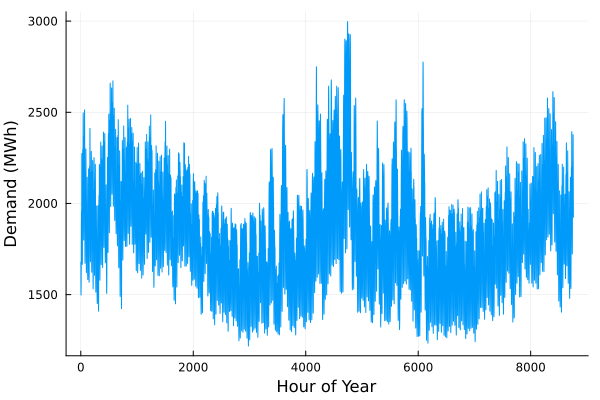

In [21]:
# load the data, pull Zone C, and reformat the DataFrame
NY_demand = DataFrame(CSV.File("data/2013_hourly_load_NY.csv"))
rename!(NY_demand, :"Time Stamp" => :Date)
demand = NY_demand[:, [:Date, :C]]
rename!(demand, :C => :Demand)
demand[:, :Hour] = 1:nrow(demand)

# plot demand
plot(demand.Hour, demand.Demand, xlabel="Hour of Year", ylabel="Demand (MWh)", label=:false)

Next, we load the generator data, shown in
<a href="#tbl-generators" class="quarto-xref">Table 3</a>. This data
includes fixed costs (\$/MW installed), variable costs (\$/MWh
generated), and CO<sub>2</sub> emissions intensity (tCO<sub>2</sub>/MWh
generated).

In [22]:
gens = DataFrame(CSV.File("data/generators.csv"))

Row,Plant,FixedCost,VarCost,Emissions
,String15,Int64,Int64,Float64
1,Geothermal,450000,0,0.0
2,Coal,220000,24,1.0
3,NG CCGT,82000,30,0.43
4,NG CT,65000,40,0.55
5,Wind,91000,0,0.0
6,Solar,70000,0,0.0


Finally, we load the hourly solar and wind capacity factors, which are
plotted in <a href="#fig-cf" class="quarto-xref">Figure 2</a>. These
tell us the fraction of installed capacity which is expected to be
available in a given hour for generation (typically based on the average
meteorology).

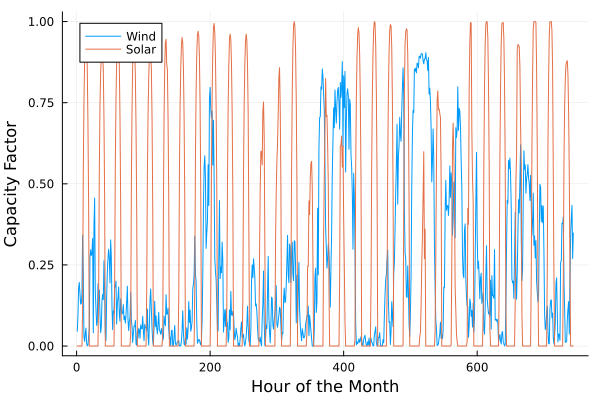

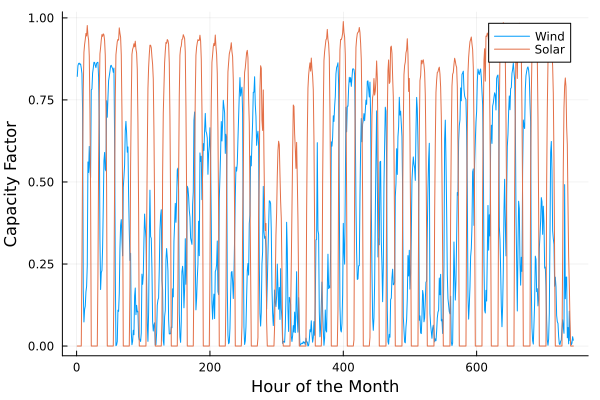

In [23]:
# load capacify factors into a DataFrame
cap_factor = DataFrame(CSV.File("data/wind_solar_capacity_factors.csv"))

# plot January capacity factors
p1 = plot(cap_factor.Wind[1:(24*31)], label="Wind")
plot!(cap_factor.Solar[1:(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

p2 = plot(cap_factor.Wind[4344:4344+(24*31)], label="Wind")
plot!(cap_factor.Solar[4344:4344+(24*31)], label="Solar")
xaxis!("Hour of the Month")
yaxis!("Capacity Factor")

display(p1)
display(p2)


**Derivation**

The goal is to minimize the total cost of power generation, installation, and unmet demand (non-served energy) over a full year, using different types of generators (renewable and non-renewable) while meeting hourly electricity demand.

**Sets**

*G* : The set of generators, where $g \in $ *G*. We have 6 generators, *G* = \{1, 2, 3, 4, 5, 6\}. Generators 1 through 4 are non-renewable, while 5 and 6 represent wind and solar energy, respectively.

*T* : The set of hours in the year \(*T* = 1, 2,..., 8760\).

**Decision Variables**

$C_g$ : Installed capacity of generator *g* in MW

$P_{g,t}$ : Generated power by generator *g* in hour *t* in MWh

$NSE_t$ : Non-served energy in hour *t* in MWh (i.e., the energy not met by generation).

**Objective Function**
Total cost = Fixed cost + Variable cost + NSE Cost

$$
\text{Minimize} \quad \sum_{g \in G} \text{FixedCost}_g \cdot C_g + \sum_{g \in G} \sum_{t \in T} \text{VarCost}_g \cdot P_{g,t} + \sum_{t \in T} \text{NSECost} \cdot \text{NSE}_t
$$

**Constraints**

**1. Demand Constraint**
At each time *t*, the total generated power plus non-served energy must meet or exceed the demand
md"""
$$
\sum P_{g,t} + \text{NSE}[t] \geq \text{Demand}[t] \quad \forall t \in T
$$

This ensures that the sum of power generated by all generators and the non-served energy will at least meet the hourly demand.

**2. Installed Capacity Constraints**
For each non-renewable generator (excluding geothermal) *g* (i.e., *g* $\in$ \{2,3,4\}), the average hourly power generator over the year must not exceed the installed capacity

$$
\sum_{t \in T} P[g,t] \leq C[g] \quad \forall g \in \{2, 3, 4\}
$$


For the remaining generators (geothermal, wind, and solar, *g* = 1, *g* = 5, and *g* = 6), the power generated at each time *t* must not exceed the installed capacity multiplied by the hourly capacity factor:
$$
P[1,t] \leq C[5] \cdot cf_{geothermal} \quad \forall t \in T
$$
$$
P[5,t] \leq C[5] \cdot cf_{wind}[t] \quad \forall t \in T
$$
$$
P[6,t] \leq C[6] \cdot cf_{solar}[t] \quad \forall t \in T
$$
where $cf_{wind}[t]$ and $cf_{solar}[t]$ are the hourly capacity factors for wind and $cf_{geothermal}$ is a constant = 0.85

We created a matrix containing the capacity factors for each generation type. For generators 2-4 (Coal, NG CCGT, NG CT), the capacity factor is 1 as seen in the equation above $P[g,t] *1 \leq C[g] = P[g,t] \leq C[g]$. Our code below shows that we combined all capacity factors into one constraint.

**3. Non-negativity Constraints**

$C_g \geq 0 \; \forall$ *g* $\in$ *G*

$P_g,t \geq 0 \; \forall$ *g* $\in$ *G*, $\forall$ *t* $\in$ *T*

$NSE_t \geq 0 \; \forall$ *t* $\in$ *T*

In [24]:
G = 1:6  # Number of generators
T = 1:8760  # Timeframe in hours

# Initialize capacity matrix
capmatrix = ones(T[end], G[end-2])
capmatrix[:,1] .= 0.85
capmatrix2 = hcat(capmatrix, cap_factor[!, :Wind], cap_factor[!, :Solar])

energy_model = Model(HiGHS.Optimizer)

# Installed capacity (MW) and generated power (MWh)
@variable(energy_model, C[g in G] >= 0)  # Installed capacity (MW)
@variable(energy_model, P[g in G, t in T] >= 0)  # Generated power (MWh)
@variable(energy_model, NSE[t in T] >= 0)  # Non-served energy (MWh)

NSE_cost = 10000  # $/MWh for non-served energy (penalty cost)

# Objective function
@objective(energy_model, Min, sum(gens[!,:FixedCost] .* C) + sum(gens[!, :VarCost] .* [sum(P[g, :]) for g in G]) + (NSE_cost * sum(NSE)))

# Demand constraint
@constraint(energy_model, demand_constraint[t in T], sum(P[g, t] for g in G) + NSE[t] >= demand.Demand[t])

# Generation constraints
@constraint(energy_model, capacity_constraint[g in G, t in T], P[g, t] <= C[g] * capmatrix2[t, g])

# Optimize the model
optimize!(energy_model)

# Display the results
println("Optimal installed capacity: ", value.(C))
#println("Total cost: ", objective_value(energy_model))
println("NSE: ", sum(value.(NSE)))


Running HiGHS 1.7.2 (git hash: 5ce7a2753): Copyright (c) 2024 HiGHS under MIT licence terms
Coefficient ranges:
  Matrix [5e-05, 1e+00]
  Cost   [2e+01, 4e+05]
  Bound  [0e+00, 0e+00]
  RHS    [1e+03, 3e+03]
Presolving model
56856 rows, 56862 cols, 153048 nonzeros  0s
56853 rows, 56859 cols, 153042 nonzeros  0s
Presolve : Reductions: rows 56853(-4467); columns 56859(-4467); elements 153042(-8934)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0     0.0000000000e+00 Pr: 8760(4.1747e+06) 0s
      42008     6.5458487038e+08 Pr: 0(0); Du: 0(2.80224e-10) 2s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 42008
Objective value     :  6.5458487038e+08
HiGHS run time      :          2.53
Optimal installed capacity: 1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, 1:6
And data, a 6-element Vector{Float64}:
   -0.0
    0.0

**Solution**

We found that the utility breakdown was:
- 0 MW for Geothermal 
- 0 MW for Coal 
- 1659 MW for NG CCGT
- 880 MW for NG CT
- 485 MW for Wind
- 1958 MW for Solar 


We found that the objective value, which was minimized cost, was $6.5*10^8$ dollars, or $650M

THe total non-served energy is 256.8 MWh

In [25]:
#What fraction of annual generation does each plant type produce?
Total_annual_gen = sum(value.(P))
# Sum generated power for each generator across all hours
total_power_per_generator = [sum(value.(P[g, :])) for g in G]
println("Total generated power per generator (MWh): ", total_power_per_generator)
fraction_gen = (total_power_per_generator ./ Total_annual_gen) .* 100
println("Fraction of generated power per generator (%): ", fraction_gen)

#How does this compare to the breakdown of built capacity that you found in Problem 1.5? 
fraction_cap = (value.(C) ./ sum(value.(C))) .* 100
println("Fraction of built capacity per generator (%): ", fraction_cap)

Total generated power per generator (MWh): [0.0, 0.0, 8.656647084004143e6, 449375.8891095476, 1.4272043521321972e6, 5.834421740979558e6]
Fraction of generated power per generator (%): [0.0, 0.0, 52.88876275987045, 2.7455127324108597, 8.719666131388552, 35.64605837632996]
Fraction of built capacity per generator (%): 1-dimensional DenseAxisArray{Float64,1,...} with index sets:
    Dimension 1, 1:6
And data, a 6-element Vector{Float64}:
 -0.0
  0.0
 33.29692965539611
 17.662923711651136
  9.736322863215605
 39.30382376973714


**Solution**

We found that each plant type produces the following fractions of annual generation:
- 0% for Geothermal 
- 0% MW for Coal 
- 53% MW for NG CCGT
- 3% MW for NG CT
- 9% MW for Wind
- 36% MW for Solar 

We found that each plant is installed with the following fractions of built capacity:
- 0% for Geothermal 
- 0% MW for Coal 
- 33% MW for NG CCGT
- 18% MW for NG CT
- 10% MW for Wind
- 39% MW for Solar 

The results indicate that natural gas plants dominate generation, contributing to over half of the annual output. This high usage is consistent with its relatively low variable cost and moderate emissions, making it economically favorable. The NG CT plant, with a higher variable cost, is utilized more sparingly and is likely reserved for peak or high-demand periods due to its higher cost.

Wind and solar contribute significantly to generation, with solar at 36% and wind at 9%, which aligns with their zero variable costs and emission-free generation profiles. Their higher share in installed capacity (39% for solar, 10% for wind) reflects the need to account for intermittency, installing more capacity to meet demand reliably.

The absence of coal and geothermal in both generation and capacity could be attributed to coal's high emissions factor (1.0) and geothermal’s high fixed costs, making them less competitive given the mix of low-cost, low-emission alternatives. Overall, the results align with the generator data and expected economic dispatch priorities.


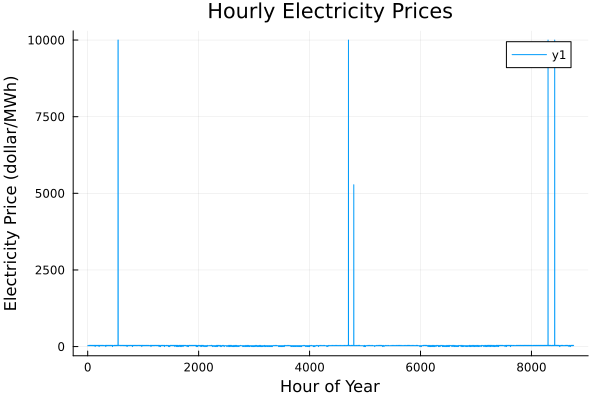

In [26]:
# Make a plot of the electricity price in each hour
elec_price = abs.(shadow_price.(demand_constraint).data)
plot(demand.Hour, elec_price, title = "Hourly Electricity Prices", xlabel = "Hour of Year", ylabel = "Electricity Price (dollar/MWh)")


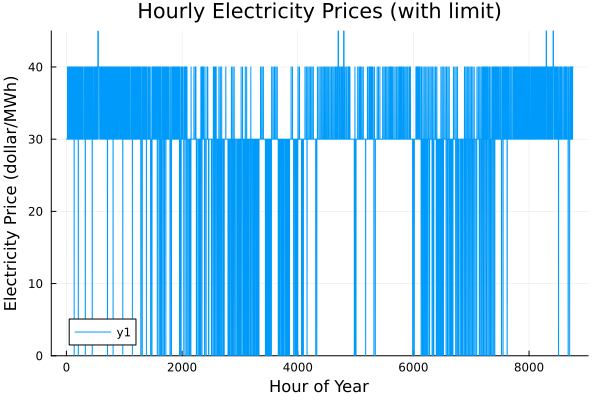

In [27]:
plot(demand.Hour, elec_price, title = "Hourly Electricity Prices (with limit)", xlabel = "Hour of Year", ylabel = "Electricity Price (dollar/MWh)", ylim=(0,45))


**Trends:**

When we limit the y axis to exlude the spikes in electricity price, we are able to more easily identify trends. By comparing this graph to the graph of hourly demand, we can see that when demand increases, the price of electricity also increases. This can be attributed to the fact that high demand cannot be met with only renewables, therefore reliance on non-renewables, which have higher variable costs, increases, causing the price of electricity to increase. 

### Problem 3 (10 points)

**This problem is only required for students in BEE 5750**.

The NY state legislature is considering enacting an annual
CO<sub>2</sub> limit, which for the utility would limit the emissions in
its footprint to 1.5 MtCO<sub>2</sub>/yr.

**In this problem**:

-   Reformulate your linear program from Problem 2 with any necessary
    changes to capture the CO<sub>2</sub> limit.
-   Implement the new optimization problem and find the optimal
    solution. How much should the utility build of each type of
    generating plant? What is different from your plan from Problem 1?
    Do these changes make sense?
-   What would the value to the utility be of allowing it to emit an
    additional 1000 tCO<sub>2</sub>/yr? An additional 5000?

## References

List any external references consulted, including classmates.